In [1]:
from scipy.stats import norm, expon
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

In [10]:
def generate_helper_functions(mu):
    def F1_inv(alpha):
        return norm.ppf(alpha)

    def F1(c):
        return norm.cdf(c)

    def f1(c):
        return norm.pdf(c)

    def F2(c):
        return norm.cdf(c, loc=mu, scale=1)

    def F2_inv(alpha):
        return norm.ppf(alpha, loc=mu, scale=1)

    def f2(c):
        return norm.pdf(c, loc=mu, scale=1)
    
    return F1_inv, F1, f1, F2_inv, F2, f2


mu=0.
F1_inv, F1, f1, F2_inv, F2, f2 = generate_helper_functions(mu)

p1 = 0.1
p2 = 0.9
eps = 0.2
c_bar = 3.


def get_alpha2(alpha1):
    if (eps - p1 * alpha1)/p2 > F2(c_bar):
        return F2(c_bar)
    elif 0<= (eps - p1 * alpha1)/p2 and (eps - p1 * alpha1)/p2 < F2(c_bar):
        return (eps - p1 * alpha1)/p2
    else:
        return None
    
def obj(alpha1, alpha2):
    return p1 * F1_inv(alpha1) + p2 * F2_inv(alpha2)
    

possible_alphas = np.linspace(0, F1(c_bar), 1000)
alphas1 = []
alphas2 = []
objs = []

for possible_alpha in possible_alphas:
    alpha2 = get_alpha2(possible_alpha)
    if alpha2 is not None:
        obj_val = obj(possible_alpha, alpha2)
        alphas2.append(alpha2)
        objs.append(obj_val)
        alphas1.append(possible_alpha)

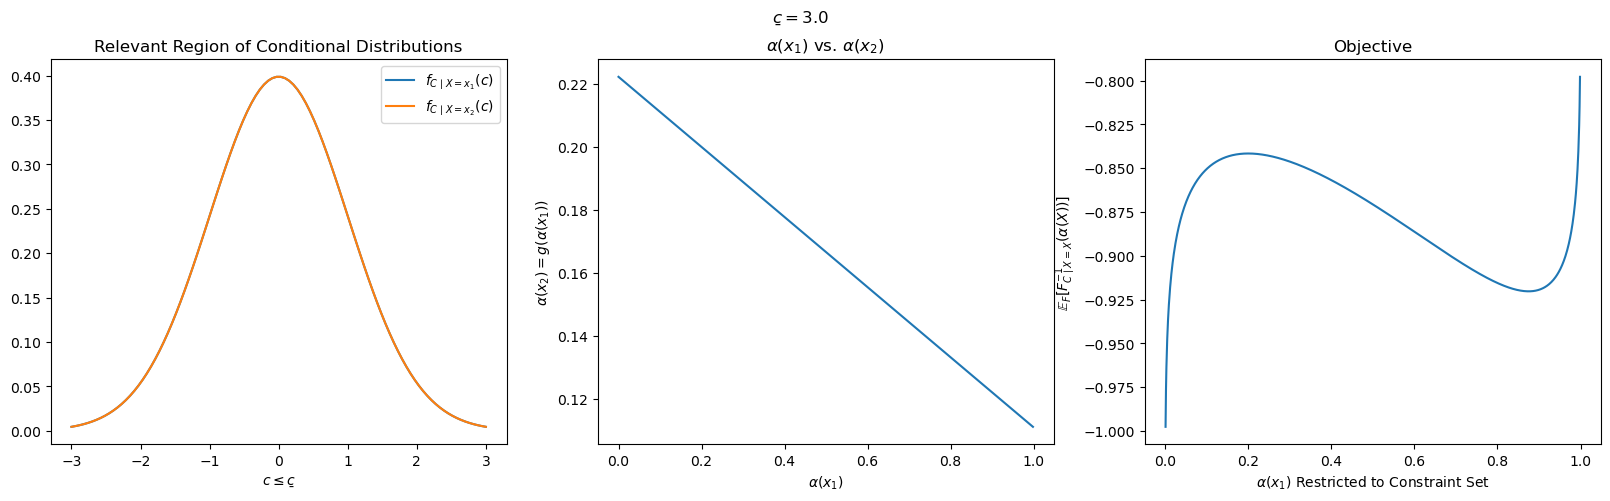

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
xs = np.linspace(-3, c_bar, 100)
ax[0].plot(xs,[f1(x) for x in xs], label=r"$f_{C \mid X=x_{1}}(c)$")
ax[0].plot(xs, [f2(x) for x in xs], label=r"$f_{C \mid X=x_{2}}(c)$")
ax[0].set_xlabel(r"$c \leq c\underbar$")
ax[0].legend()
ax[0].set_title("Relevant Region of Conditional Distributions")


# alphas1 = np.linspace(0, F1(c_bar), 1000)
# alphas2 = np.linspace(0, F2(c_bar), 1000)

ax[1].plot(alphas1, alphas2)
ax[1].set_xlabel(r"$\alpha(x_{1})$")
ax[1].set_title(r"$\alpha(x_{1})$" + " vs. " + r"$\alpha(x_{2})$")
ax[1].set_ylabel(r"$\alpha(x_{2}) = g(\alpha(x_{1}))$")


ax[2].plot(alphas1, objs)
ax[2].set_xlabel(r"$\alpha(x_{1})$" + " Restricted to Constraint Set")
ax[2].set_ylabel(r"$\mathbb{E}_{F}[F_{C \mid X=X}^{-1}(\alpha(X))]$" )
ax[2].set_title("Objective" )

plt.suptitle(r"$c\underbar={}$".format(c_bar))
plt.savefig("figs/cbar_{}.pdf".format(c_bar), bbox_inches="tight")

In [38]:
F1_inv(2 * eps)

-0.2533471031357997

In [39]:
F1_inv(eps)

-0.8416212335729142

In [40]:
c_bar

0.0